In [1]:
from __future__ import print_function
import numpy as np
from numpy import newaxis as na
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding, LSTM
from keras.datasets import imdb
from keras.models import Model
from keras import backend as K

import matplotlib.pyplot as plt
from IPython.display import display, HTML

Using TensorFlow backend.


In [2]:
import os
import sys
import numpy as np
import keras
import shap
from keras.preprocessing.text import Tokenizer
from keras.utils import to_categorical
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Activation, Conv2D, Input, Embedding, Reshape, MaxPool2D, Concatenate, Flatten, Dropout, Dense, Conv1D
from keras.layers import MaxPool1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

from keras.layers import Embedding
# preparing input to our model
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

# keras layers
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense
# preparing input to our model
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

import pandas as pd

# keras layers
from keras.models import Sequential
from keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

In [3]:
# Let's import and prep the datasets

train=pd.read_csv('not_clean_train_four.csv', sep=',', encoding='utf-8')
test=pd.read_csv('not_clean_test_four.csv', sep=',', encoding='utf-8')

train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4698 entries, 0 to 4697
Data columns (total 3 columns):
text      4698 non-null object
label     4698 non-null object
target    4698 non-null int64
dtypes: int64(1), object(2)
memory usage: 110.2+ KB


,text,label,target
0,শালা মাতারচুদ খানকির পোলা ফলো করার মানুষ পাইলিনা,Personal,0
1,"আবে ছালে রানু মন্ডল তো মেন্টাল, একজন পাগল এর ...",Personal,0
2,ভারতীয় আধিপত্যবাদের বিরুদ্ধে সোচ্চার হতে দেখা ...,Geopolitical,3
3,ফেমিলি সো শালার তোর ভিডিওর শুরুতে আহ সাউন্ড।,Personal,0
4,স্কুল ছুটির পর গেট দিয়ে বের হওয়ার সময পিছন থেক...,Personal,0


In [4]:
test.info()
test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
text      1000 non-null object
label     1000 non-null object
target    1000 non-null int64
dtypes: int64(1), object(2)
memory usage: 23.5+ KB


,text,label,target
0,বৌদির দুধ দেকে তো আমার ই চোখ ঠিক ছিলো না - পোল...,Personal,0
1,এই সরকার কে যারা নির্লজ্জের মত সাপোর্ট দিয়েছে ...,Political,1
2,পিলখানা হত্যাকান্ড বাংলাদেশের প্রতিরক্ষা ব্যবস...,Geopolitical,3
3,ভারতের অর্থনীতি নিয়ে আপনাদের ভাবতে হবে না। ভা...,Geopolitical,3
4,খানকির পুলা মালায়নদের মেরে সাফা করে ফেল,Personal,0


In [5]:
import csv 

stop_words='stopwords-bn.txt'
text_data=[]

with open(stop_words,'r',encoding='utf-8') as temp_output_file:
    reader=csv.reader(temp_output_file, delimiter='\n')
    for row in reader:
        text_data.append(row)
stop_word_list=[x[0] for x in text_data]

In [10]:
from nltk.corpus import stopwords  
from nltk.tokenize import word_tokenize  
from nltk.tokenize.treebank import TreebankWordDetokenizer
  
stop_words = set(stop_word_list)  

def textCleaner(example_sent): 
    word_tokens = word_tokenize(example_sent)  
    filtered_sentence = [w for w in word_tokens if not w in stop_words]
    filtered_train = TreebankWordDetokenizer().detokenize(filtered_sentence)

    return filtered_train        

In [11]:
filtered_test = test['text'].apply(textCleaner)

In [12]:
filtered_train = train['text'].apply(textCleaner)

In [13]:
filtered_test

0          বৌদির দুধ দেকে চোখ ছিলো - পোলাপান চোখ কিভাবে!
1      সরকার নির্লজ্জের মত সাপোর্ট দিয়েছে বছরের বছর, ...
2      পিলখানা হত্যাকান্ড বাংলাদেশের প্রতিরক্ষা ব্যবস...
3      ভারতের অর্থনীতি আপনাদের ভাবতে না। ভারতের অর্থন...
4                    খানকির পুলা মালায়নদের মেরে সাফা ফেল
5      শুয়োর বাচ্চা দুরগারে চুদি কুত্তা দিয়া কালিরে...
6                  মাগীর পাছায় লাথি মেরে প্লাটফর্মে আসা
7      দেখলাম ইউটিউব গাড়ি আওয়ামী লীগ লোকজনে পোড়ালো।...
8      সানিউর কুত্তার বাচ্চা, তুর বোনেরে চুদমু তুর কা...
9      ভারতে মুসলমান খেদাও আন্দোলনের নামে প্রচার মুসল...
10                   তারউপর কেমন টাইটেল দিছস তোর ভিডিওর?
11                     পেটের নোংরা টা করেও পথ টাকা ইনকাম
12     ভোট সংসদে আওয়ামী লীগের নির্লজ্জ এমপিরা চে ভাল...
13                    রানু মেয়েকে পাবনা হাসপাতালে পাঠাতে
14                   মাদারচোদ শালারা র্ধ্ম নিয়া ব্যবসা ,
15                      চাইনা ছাড়তে ক্ষমতা, যতই লাশ জনতা
16     হাসিনা জঙ্গিবাদ উগ্রবাদ রাজাকার ডায়ালগ মাইরা ক...
17                     শেখ হাসি

In [14]:
train['label'].value_counts()

Personal        1798
Geopolitical    1457
Religious        784
Political        659
Name: label, dtype: int64

In [15]:
train['target'].value_counts()

0    1798
3    1457
2     784
1     659
Name: target, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(filtered_train, train['target'].values, test_size=0.2, random_state=42)

In [17]:
x_test, y_test = filtered_test, test['target'].values

In [18]:
max_features = 10000

maxlen = 20
batch_size = 32

In [19]:
tokenizer  = Tokenizer(num_words = max_features)
tokenizer.fit_on_texts(x_train)

train_seq =  tokenizer.texts_to_sequences(x_train)
val_seq =  tokenizer.texts_to_sequences(x_val)
test_seq = tokenizer.texts_to_sequences(x_test)

word_index = tokenizer.word_index
print("Unique words : {}".format(len(word_index)))

x_train = pad_sequences(train_seq, maxlen=maxlen, dtype='int32', padding='post') #maxlen = maxlen, padding='post')
x_val = pad_sequences(val_seq, maxlen=maxlen, dtype='int32', padding='post') #maxlen = maxlen, padding='post')
x_test = pad_sequences(test_seq, maxlen=maxlen, dtype='int32', padding='post') #maxlen = maxlen, padding='post')

y_train = np.asarray(y_train)
y_val = np.asarray(y_val)
y_test = np.asarray(y_test)

#y_train = to_categorical(np.asarray(y_train), num_classes=5)
#y_val = to_categorical(np.asarray(y_val), num_classes=5)
#y_test = to_categorical(np.asarray(y_test), num_classes=5)

print('Shape of training data tensor:', x_train.shape)
print('Shape of training label tensor:', y_val.shape)

print('Shape of val data tensor:', x_val.shape)
print('Shape of val label tensor:', y_val.shape)

print('Shape of test data tensor:', x_test.shape)
print('Shape of test label tensor:', y_test.shape)

Unique words : 14100
Shape of training data tensor: (3758, 20)
Shape of training label tensor: (940,)
Shape of val data tensor: (940, 20)
Shape of val label tensor: (940,)
Shape of test data tensor: (1000, 20)
Shape of test label tensor: (1000,)


In [20]:
from gensim.models.keyedvectors import KeyedVectors
from gensim.models import Word2Vec

word_vectors = Word2Vec.load('/home/rkarim/BengHateExplainer/data/Bengali_FastText_DIM20.model')

#word_vectors = Word2Vec.load('C:/Users/admin-karim/Desktop/BengWord2Vec/posts.bin')

In [21]:
NUM_WORDS=20000
EMBEDDING_DIM=20

vocabulary_size=len(tokenizer.word_index)+1
word_index=tokenizer.word_index
embedding_matrix = np.zeros((vocabulary_size, EMBEDDING_DIM))

for word, i in word_index.items():
    if i>=NUM_WORDS:
        continue
    try:
        embedding_vector=word_vectors[word]
        embedding_matrix[i]=embedding_vector
    except KeyError:
        embedding_matrix[i]=np.random.normal(0,np.sqrt(0.25),EMBEDDING_DIM)

del(word_vectors)

In [22]:
embedding_layer=Embedding(vocabulary_size, EMBEDDING_DIM, weights=[embedding_matrix],trainable=False)

In [23]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import TimeDistributed
from keras.layers import Bidirectional
from keras.layers import Embedding
from keras.initializers import Constant
from keras.layers import *

In [24]:
def BiLSTM_Model():
    model = Sequential()
    model.add(embedding_layer)
    model.add(SpatialDropout1D(0.5))
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(Dropout(0.2))
    model.add(Bidirectional(LSTM(32)))
    #model.add(Dropout(0.2))
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.25))
    model.add(Dense(units=4, activation='softmax'))
    model.compile(loss = 'sparse_categorical_crossentropy', optimizer='adam', metrics = ['accuracy'])
    
    print(model.summary())
    
    return model     

In [25]:
model = BiLSTM_Model()





Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, None, 20)          282020    
_________________________________________________________________
spatial_dropout1d_1 (Spatial (None, None, 20)          0         
_________________________________________________________________
bidirectional_1 (Bidirection (None, None, 128)         43520     
_________________________________________________________________
dropout_1 (Dropout)          (None, None, 128)         0         
_________________________________________________________________
bidirectional_2 (Bidirection (None, 64)                41216     
_________________________________________________________________
dense_1 (Dense)              (None, 128)               8320      
______________________

In [26]:
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=100, verbose=1, validation_data=(x_val, y_val))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Train on 3758 samples, validate on 940 samples
Epoch 1/100
3758/3758 [==============================] - 5s 1ms/step - loss: 1.1830 - acc: 0.5027 - val_loss: 0.9671 - val_acc: 0.6043
Epoch 2/100
3758/3758 [==============================] - 2s 659us/step - loss: 1.0626 - acc: 0.5697 - val_loss: 0.8799 - val_acc: 0.6564
Epoch 3/100
3758/3758 [==============================] - 2s 660us/step - loss: 1.0213 - acc: 0.5894 - val_loss: 0.8586 - val_acc: 0.6830
Epoch 4/100
3758/3758 [==============================] - 2s 658us/step - loss: 0.9821 - acc: 0.6078 - val_loss: 0.8774 - val_acc: 0.6628
Epoch 5/100
3758/3758 [==============================] - 2s 659us/step - loss: 0.9691 - acc: 0.6235 - val_loss: 0.8262 - val_acc: 0.6798
Epoch 6/100
3758/3758 [==============================] - 2s 657us/step - loss: 0.9471 - acc: 0.6325 - val_loss: 0.8100 - val_acc: 0.7000
Epoch 7/100
3758/3758 [================

Epoch 58/100
3758/3758 [==============================] - 2s 656us/step - loss: 0.7141 - acc: 0.7233 - val_loss: 0.6786 - val_acc: 0.7596
Epoch 59/100
3758/3758 [==============================] - 2s 657us/step - loss: 0.7189 - acc: 0.7145 - val_loss: 0.6689 - val_acc: 0.7574
Epoch 60/100
3758/3758 [==============================] - 2s 656us/step - loss: 0.7057 - acc: 0.7347 - val_loss: 0.6928 - val_acc: 0.7585
Epoch 61/100
3758/3758 [==============================] - 2s 657us/step - loss: 0.7150 - acc: 0.7249 - val_loss: 0.6667 - val_acc: 0.7606
Epoch 62/100
3758/3758 [==============================] - 2s 657us/step - loss: 0.6891 - acc: 0.7360 - val_loss: 0.6859 - val_acc: 0.7628
Epoch 63/100
3758/3758 [==============================] - 2s 659us/step - loss: 0.7190 - acc: 0.7201 - val_loss: 0.6882 - val_acc: 0.7532
Epoch 64/100
3758/3758 [==============================] - 2s 656us/step - loss: 0.6868 - acc: 0.7403 - val_loss: 0.6817 - val_acc: 0.7585
Epoch 65/100
3758/3758 [==========

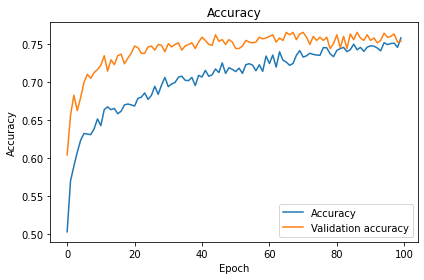

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['acc'], label="Accuracy")
plt.plot(history.history['val_acc'], label="Validation accuracy")
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

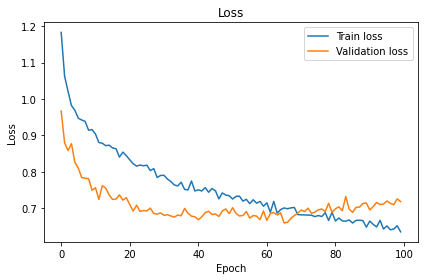

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label="Train loss")
plt.plot(history.history['val_loss'], label="Validation loss")
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

In [30]:
y_pred

array([0, 0, 3, 3, 0, 0, 0, 1, 0, 3, 0, 0, 1, 0, 0, 0, 1, 3, 1, 0, 3, 0,
       0, 0, 3, 0, 1, 3, 2, 2, 0, 3, 1, 0, 0, 3, 3, 0, 2, 3, 2, 0, 0, 0,
       0, 3, 2, 1, 0, 3, 2, 3, 0, 0, 3, 3, 0, 2, 0, 0, 0, 0, 0, 0, 1, 2,
       0, 0, 0, 3, 3, 0, 3, 3, 0, 3, 2, 1, 0, 2, 2, 0, 2, 0, 2, 0, 0, 3,
       3, 0, 0, 0, 3, 2, 3, 0, 0, 3, 0, 0, 3, 2, 2, 3, 0, 0, 3, 1, 3, 1,
       3, 3, 0, 2, 3, 0, 0, 2, 3, 0, 0, 3, 3, 1, 0, 0, 0, 0, 0, 3, 1, 1,
       3, 3, 0, 3, 3, 3, 2, 0, 0, 0, 3, 3, 2, 0, 3, 0, 0, 3, 2, 0, 0, 0,
       3, 0, 0, 3, 0, 3, 0, 3, 0, 0, 0, 3, 3, 3, 2, 1, 0, 0, 0, 3, 0, 0,
       3, 3, 0, 1, 1, 0, 0, 0, 0, 3, 0, 0, 3, 3, 0, 0, 0, 0, 0, 1, 0, 3,
       2, 2, 3, 0, 0, 3, 0, 0, 0, 3, 1, 2, 3, 2, 0, 0, 2, 0, 1, 2, 3, 2,
       3, 0, 2, 1, 3, 0, 3, 2, 2, 3, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0,
       3, 3, 2, 2, 0, 3, 0, 2, 0, 1, 1, 2, 2, 0, 0, 0, 0, 3, 0, 1, 1, 0,
       2, 2, 2, 3, 0, 0, 0, 2, 3, 0, 0, 0, 0, 3, 3, 2, 0, 0, 3, 0, 0, 0,
       2, 0, 0, 1, 0, 0, 3, 2, 3, 3, 3, 3, 1, 2, 0,

In [31]:
categories = ['Personal', 'Geopolitical','Religious','Political']
print(classification_report(y_test, y_pred, target_names=categories))

              precision    recall  f1-score   support

    Personal       0.76      0.88      0.82       391
Geopolitical       0.79      0.48      0.59       155
   Religious       0.57      0.53      0.55       173
   Political       0.77      0.79      0.78       281

    accuracy                           0.73      1000
   macro avg       0.72      0.67      0.69      1000
weighted avg       0.73      0.73      0.73      1000



In [32]:
test['target'].value_counts()

0    391
3    281
2    173
1    155
Name: target, dtype: int64

In [33]:
def get_layer_output(layer_name, data):
    # https://keras.io/getting-started/faq/#how-can-i-obtain-the-output-of-an-intermediate-layer
    intermediate_layer_model = keras.Model(inputs=model.input,
                                     outputs=model.get_layer(layer_name).output)
    return intermediate_layer_model.predict(data)  

In [34]:
names = [weight.name for layer in model.layers for weight in layer.weights]
weights = model.get_weights()

for name, weight in zip(names, weights):
    print(name)
    #print(weight)

embedding_1/embeddings:0
bidirectional_1/forward_lstm_1/kernel:0
bidirectional_1/forward_lstm_1/recurrent_kernel:0
bidirectional_1/forward_lstm_1/bias:0
bidirectional_1/backward_lstm_1/kernel:0
bidirectional_1/backward_lstm_1/recurrent_kernel:0
bidirectional_1/backward_lstm_1/bias:0
bidirectional_2/forward_lstm_2/kernel:0
bidirectional_2/forward_lstm_2/recurrent_kernel:0
bidirectional_2/forward_lstm_2/bias:0
bidirectional_2/backward_lstm_2/kernel:0
bidirectional_2/backward_lstm_2/recurrent_kernel:0
bidirectional_2/backward_lstm_2/bias:0
dense_1/kernel:0
dense_1/bias:0
dense_2/kernel:0
dense_2/bias:0


In [35]:
# suppress scientific notation
np.set_printoptions(suppress=True)
for name, weight in zip(names, weights):
    if name == 'bidirectional_1/backward_lstm_1/kernel:0':
        kernel_0 = weight
    if name == 'bidirectional_1/backward_lstm_1/recurrent_kernel:0':
        recurrent_kernel_0 = weight
    if name == 'bidirectional_1/backward_lstm_1/bias:0':
        bias_0 = weight
    elif name == 'dense_1/kernel:0':
        output = weight

In [36]:
print("kernel_0", kernel_0.shape)
print("recurrent_kernel_0", recurrent_kernel_0.shape)
print("bias_0", bias_0.shape)
print("output", output.shape)

# self.Wxh_Left (240, 60)
# self.Whh_Left (240, 60)
# self.bxh_Left (240,)
# self.Why_Left (5, 60)

kernel_0 (20, 256)
recurrent_kernel_0 (64, 256)
bias_0 (256,)
output (64, 128)


In [37]:
Wxh = kernel_0.T  # shape 4d*e
Whh = recurrent_kernel_0.T  # shape 4d
bxh = bias_0.T  # shape 4d 
Why = output.T

print("Wxh", Wxh.shape)
print("Whh", Whh.shape)
print("bxh", bxh.shape)
print("Why", Why.shape)

Wxh (256, 20)
Whh (256, 64)
bxh (256,)
Why (128, 64)


In [38]:
def html_heatmap (words, scores, cmap_name="bwr"):
    """
    Return word-level heatmap in HTML format,
    with words being the list of words (as string),
    scores the corresponding list of word-level relevance values,
    and cmap_name the name of the matplotlib diverging colormap.
    """
    
    colormap  = plt.get_cmap(cmap_name)
     
    #assert len(words)==len(scores)
    max_s     = max(scores)
    min_s     = min(scores)
    
    output_text = ""
    
    for idx, w in enumerate(words):
        score       = rescale_score_by_abs(scores[idx], max_s, min_s)
        output_text = output_text + span_word(w, score, colormap) + " "
    
    return output_text + "\n"

def rescale_score_by_abs (score, max_score, min_score):
    """
    Normalize the relevance value (=score), accordingly to the extremal relevance values (max_score and min_score), 
    for visualization with a diverging colormap.
    i.e. rescale positive relevance to the range [0.5, 1.0], and negative relevance to the range [0.0, 0.5],
    using the highest absolute relevance for linear interpolation.
    """
    
    # CASE 1: positive AND negative scores occur --------------------
    if max_score>0 and min_score<0:
    
        if max_score >= abs(min_score):   # deepest color is positive
            if score>=0:
                return 0.5 + 0.5*(score/max_score)
            else:
                return 0.5 - 0.5*(abs(score)/max_score)

        else:                             # deepest color is negative
            if score>=0:
                return 0.5 + 0.5*(score/abs(min_score))
            else:
                return 0.5 - 0.5*(score/min_score)   
    
    # CASE 2: ONLY positive scores occur -----------------------------       
    elif max_score>0 and min_score>=0: 
        if max_score == min_score:
            return 1.0
        else:
            return 0.5 + 0.5*(score/max_score)
    
    # CASE 3: ONLY negative scores occur -----------------------------
    elif max_score<=0 and min_score<0: 
        if max_score == min_score:
            return 0.0
        else:
            return 0.5 - 0.5*(score/min_score)
          

def getRGB (c_tuple):
    return "#%02x%02x%02x"%(int(c_tuple[0]*255), int(c_tuple[1]*255), int(c_tuple[2]*255))

     
def span_word (word, score, colormap):
    return "<span style=\"background-color:"+getRGB(colormap(score))+"\">"+word+"</span>"

In [39]:
def lrp_linear(hin, w, b, hout, Rout, bias_nb_units, eps, bias_factor=0.0, debug=False):
    """
    LRP for a linear layer with input dim D and output dim M.
    Args:
    - hin:            forward pass input, of shape (D,)
    - w:              connection weights, of shape (D, M)
    - b:              biases, of shape (M,)
    - hout:           forward pass output, of shape (M,) (unequal to np.dot(w.T,hin)+b if more than one incoming layer!)
    - Rout:           relevance at layer output, of shape (M,)
    - bias_nb_units:  total number of connected lower-layer units (onto which the bias/stabilizer contribution is redistributed for sanity check)
    - eps:            stabilizer (small positive number)
    - bias_factor:    set to 1.0 to check global relevance conservation, otherwise use 0.0 to ignore bias/stabilizer redistribution (recommended)
    Returns:
    - Rin:            relevance at layer input, of shape (D,)
    """
    sign_out = np.where(hout[na,:]>=0, 1., -1.) # shape (1, M)
    
    numer    = (w * hin[:,na]) + ( bias_factor * (b[na,:]*1. + eps*sign_out*1.) / bias_nb_units ) # shape (D, M)
    # Note: here we multiply the bias_factor with both the bias b and the stabilizer eps since in fact
    # using the term (b[na,:]*1. + eps*sign_out*1.) / bias_nb_units in the numerator is only useful for sanity check
    # (in the initial paper version we were using (bias_factor*b[na,:]*1. + eps*sign_out*1.) / bias_nb_units instead)
    
    denom    = hout[na,:] + (eps*sign_out*1.)   # shape (1, M)
    
    message  = (numer/denom) * Rout[na,:]       # shape (D, M)
    
    Rin      = message.sum(axis=1)              # shape (D,)
    
    if debug:
        print("local diff: ", Rout.sum() - Rin.sum())
    # Note: 
    # - local  layer   relevance conservation if bias_factor==1.0 and bias_nb_units==D (i.e. when only one incoming layer)
    # - global network relevance conservation if bias_factor==1.0 and bias_nb_units set accordingly to the total number of lower-layer connections 
    # -> can be used for sanity check
    
    return Rin

In [40]:
def LRP(target_data, target_class) :
    
    #원본 소스에서 E embedding은 전체에 대한 단어 사전이고, x는 embedding된 인풋이다.  
    # w_indices [109, 11995, 25, 18263, 25, 973, 3138, 6389, 372]

    x = get_layer_output('embedding_1', target_data).squeeze(axis=1)
    e = x.shape[1]

   ################# forword
    T = target_data.shape[0]
    d = int(256/4)  # hidden units
    C = Why.shape[0] # number of classes
    
    idx    = np.hstack((np.arange(0,d), np.arange(2*d,4*d))).astype(int) # indices of gates i,f,o together
    idx_i, idx_g, idx_f, idx_o = np.arange(0,d), np.arange(d,2*d), np.arange(2*d,3*d), np.arange(3*d,4*d) # indices of gates i,g,f,o separately

    h  = np.zeros((T,d))
    c  = np.zeros((T,d))

    gates_xh  = np.zeros((T, 4*d))  
    gates_hh  = np.zeros((T, 4*d)) 
    gates_pre = np.zeros((T, 4*d))  
    gates     = np.zeros((T, 4*d))  

    for t in range(T):
        gates_xh[t]     = np.dot(Wxh, x[t])
        gates_hh[t]     = np.dot(Whh, h[t-1])
        gates_pre[t]    = gates_xh[t] + gates_hh[t] + bxh
        gates[t, idx]    = 1.0/(1.0 + np.exp(- gates_pre[t,idx]))
        gates[t,idx_g]  = np.tanh(gates_pre[t,idx_g]) 
        c[t]            = gates[t,idx_f]*c[t-1] + gates[t,idx_i]*gates[t,idx_g]
        h[t]            = gates[t,idx_o]*np.tanh(c[t])

    s = np.dot(Why, h[t])    

    ################# backwork
    dx     = np.zeros(x.shape)

    dh          = np.zeros((T, d))
    dc          = np.zeros((T, d))
    dgates_pre  = np.zeros((T, 4*d))  # gates pre-activation
    dgates      = np.zeros((T, 4*d))  # gates activation

    ds               = np.zeros((C))
    ds[target_class] = 1.0
    dy               = ds.copy()

    #맨처음을 0으로 시작하지 않게 위한조치
    dh[T-1]     = np.dot(Why.T, dy)

    for t in reversed(range(T)): 
        dgates[t,idx_o]    = dh[t] * np.tanh(c[t])  # do[t]
        dc[t]             += dh[t] * gates[t,idx_o] * (1.-(np.tanh(c[t]))**2) # dc[t]
        dgates[t,idx_f]    = dc[t] * c[t-1]         # df[t]
        dc[t-1]            = dc[t] * gates[t,idx_f] # dc[t-1]
        dgates[t,idx_i]    = dc[t] * gates[t,idx_g] # di[t]
        dgates[t,idx_g]    = dc[t] * gates[t,idx_i] # dg[t]
        dgates_pre[t,idx]  = dgates[t,idx] * gates[t,idx] * (1.0 - gates[t,idx]) # d ifo pre[t]
        dgates_pre[t,idx_g]= dgates[t,idx_g] *  (1.-(gates[t,idx_g])**2) # d g pre[t]
        dh[t-1]            = np.dot(Whh.T, dgates_pre[t])
        dx[t]              = np.dot(Wxh.T, dgates_pre[t])

    ################# LRP
    eps=0.001 
    bias_factor=0.0
    Rx  = np.zeros(x.shape)
    Rh  = np.zeros((T+1, d))
    Rc  = np.zeros((T+1, d))
    Rg  = np.zeros((T,   d)) # gate g only

    Rout_mask            = np.zeros((C))
    Rout_mask[target_class] = 1.0  

    # format reminder: lrp_linear(hin, w, b, hout, Rout, bias_nb_units, eps, bias_factor)
    Rh[T-1]  = lrp_linear(h[T-1], Why.T, np.zeros((C)), s, s*Rout_mask, 2*d, eps, bias_factor, debug=False)  

    for t in reversed(range(T)):
        Rc[t]   += Rh[t]
        Rc[t-1]  = lrp_linear(gates[t,idx_f]*c[t-1], np.identity(d), np.zeros((d)), c[t], Rc[t], 2*d, eps, bias_factor, debug=False)
        Rg[t]    = lrp_linear(gates[t,idx_i]*gates[t,idx_g], np.identity(d), np.zeros((d)), c[t], Rc[t], 2*d, eps, bias_factor, debug=False)
        Rx[t]    = lrp_linear(x[t], Wxh[idx_g].T, bxh[idx_g], gates_pre[t,idx_g], Rg[t], d+e, eps, bias_factor, debug=False)
        Rh[t-1]  = lrp_linear(h[t-1], Whh[idx_g].T, bxh[idx_g], gates_pre[t,idx_g], Rg[t], d+e, eps, bias_factor, debug=False)    

    return s, dx, Rx, Rh[-1].sum()

In [41]:
#word_index = imdb.get_word_index()
index_word = {v:k for k,v in word_index.items()}

#values = ','.join(str(v) for v in value_list)

def index_to_word(word):
    full_sentence = ' '.join(index_word.get(w) for w in word)
    return full_sentence.split()

In [42]:
def int_to_str(target_class):
    if target_class == 0:
        return "Personal"
    elif target_class == 1:
        return "Political"
    elif target_class == 2:
        return "Religious"
    elif target_class == 3:
        return "Geopolitical"
    else:
        return "Fake"

In [43]:
predictions = model.predict(x_test)

In [44]:
per_list = []
geo_list = []
reli_list = []
poli_list = []

categories = ['Personal', 'Geopolitical','Religious','Political']

for i in range(len(y_test)):
    if np.argmax(predictions[i]) == 0:
        per_list.append(i)
    elif np.argmax(predictions[i]) == 1:
        geo_list.append(i)
    elif np.argmax(predictions[i]) == 2:
        reli_list.append(i)
    else:
        poli_list.append(i)

In [45]:
index_word = {v: k for k, v in word_index.items()} # map back
seqs = x_test
words = []

def seqToWords():
    for seq in seqs:
        if len(seq):
            words.append(index_word.get(seq[0]))
        else:
            words.append(' ')    
            
    return words

In [46]:
words = seqToWords()

In [47]:
# Creating a reverse dictionary
reverse_word_map = dict(map(reversed, word_index.items()))

# Function takes a tokenized sentence and returns the words
def sequence_to_text(list_of_indices):
    # Looking up words in dictionary
    words = [reverse_word_map.get(letter) for letter in list_of_indices]
    
    return words

In [48]:
def explainer(class_list):   
    for index, i in enumerate(class_list):
    
        target_data = x_test[i]
        print(target_data)
        print(target_data.shape)
        target_class = np.argmax(y_test[i])

        scores, Gx, Rx, R_rest = LRP(target_data, target_class)
    
        R_words          = np.sum(Rx, axis=1)                       # compute word-level LRP relevances
        R_words_SA       = (np.linalg.norm(Gx,ord=2, axis=0))**2   # compute word-level Sensitivity Analysis relevances
        R_words_GI       = np.dot(target_data, Gx) 
    
        try:
            words = index_to_word(target_data)
            #continue
        #words = seqToWords()
        except:
            continue

        if len(words) > 0 :
            print("Predicted label:", int_to_str(np.argmax(predictions[i])), "Actual label:", int_to_str(target_class))

            print("LRP heatmap:")
            display(HTML(html_heatmap(words, R_words)))

            print("SA heatmap:")
            display(HTML(html_heatmap(words, R_words_SA)))

            print("GI heatmap:")
            display(HTML(html_heatmap(words, R_words_GI)))

            print("-----------------------------------------------------------")

        if index == 50: 
            break

In [49]:
print("The degree to which each word affects the prediction of being religious hates...")
explainer(reli_list)

The degree to which each word affects the prediction of being religious hates...
[9573  322 1321 1297  368 1150  157    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[3431   17 6374 2296  105    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  21 5910  902  225  454 4224 1140    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  98  156  474   63 3766 4274  405  380    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  45 2303   13 2235  971 1123    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1122  203   14 1387  297   26  647 5357    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1940 1641  868   46    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 475  222  837  751 7938 4473    2    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[201 119   0   0   0   0   0   0   0   0   0   

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[ 160  151  255  357 8728   42 4902    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  12   17  723 3775 2100 4000 1040 4087  582  152 1292 8784    0    0
    0    0    0    0    0    0]
(20,)
[  17   14 3035  415 1293 1013 3866    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  26  614   23 3594 1473  369 1842 1843  614  442    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1056  604  357   25    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1669 3928 6612 3381  205 7469 1141   22  172  148  670 1651   24 3662
  134 9735   56 2697  150   22]
(20,)
Predicted label: Religious Actual label: Personal
LRP heatmap:


SA heatmap:


...

GI heatmap:


-----------------------------------------------------------
[1741  770 2992 2465 1741 1408 3596 2202   15 2938    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  27 4726 3416  135  188 4726  262  925  262   25    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 178 1207   40  224 9782  241    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  39   45 1974 1373  326    6 7040  100    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  98  292 3287 3947   36    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  37 3180 1141 1215   48  150    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 196   46 2732  865  106  667 1654 1709  733 6119 1002 2553  328 1073
  304 2112   30 1640    0    0]
(20,)
[368 770 107   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[10 14 25 10  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
(20,)
[6034  544  120 2434

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[  94 4741 1283 7301 7161  516 4453    5  197  635    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1598  734 1567 1642 1598  460  776 1732 1598  147  193  685 1253 1253
 1598  573   34    0    0    0]
(20,)
[3999   65   73  177  526   17 7883   19   24 3874   65   74 1252    0
    0    0    0    0    0    0]
(20,)


In [50]:
print("The degree to which each word affects the prediction of being geopolitical hates...")
explainer(geo_list)

The degree to which each word affects the prediction of being geopolitical hates...
[ 717 2848   54   53  889 1832 1197    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 108  211  102  927   16  970 1853    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  58   31 1063  817 1780   60  791 1183    9    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1299 4593 1736 1943 2768  970 1853  775  186    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 624  863 1002 2311 3069  671    2    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  53  288  122 2969 2969  288  122  246  170 1876  170    0    0    0
    0    0    0    0    0    0]
(20,)
[305 116 196 113 142 599   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[  87   98 1259  973  636 1057 4499    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 299 4058 4058  498 2811  337   29 4231  534    0    0    0    

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[2184   20   54 9260 2054 1200   21   39 1827 1112    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 502   31  320 1472  459   31  755    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 116 4716 6779 2733    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 567   21  148  518   62 3095   54   53 4200    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  31   42   22 3235 1725   25    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 116 7255   38    2 4509  311 7255  113   20 2783    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 305 7385   62   91  265 1145    4    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[221 164  31 708 323   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[ 489  198   98 1275  105  489 5275   31    9  673 3076   68  352   94
    0    0    0  

SA heatmap:


...

GI heatmap:


-----------------------------------------------------------
[ 221  274   15  378   22  378  253 2243 4757  839 3939  253  307 4659
    0    0    0    0    0    0]
(20,)
[ 116 4324 5430 1108  332 2651   11  531   20 1026   58  306  170   49
 2263   22  306 3568  923  465]
(20,)
Predicted label: Political Actual label: Personal
LRP heatmap:


SA heatmap:


GI heatmap:


-----------------------------------------------------------
[59 49 25  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
(20,)
[  31   62  605  750  171  750 8012    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 624  427  619 4558  156 1128  534    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  54   53  220   53   22 9451 8490 1862    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[356 142 111   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[560  32 560  77 170 391   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[1374 1985    6  624    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 105  271 3075  105 2790 2166   19    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 709   83 2212 1203 2729    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 336  972    5   87  560 2034 2670  908

In [51]:
print("The degree to which each word affects the prediction of being personal hates...")
explainer(per_list)

The degree to which each word affects the prediction of being personal hates...
[ 240 1000  222 4219 1000  136    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  36   15  175  588  247  119  264  264 3980    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  28  312   62 1441    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1317   23  241  131 1937 9013  241 1069 1937    7  183  241  387 1937
 2081    0    0    0    0    0]
(20,)
[ 669  261   62 7606 1232    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  99   23  317 9424  317  317 2070  317  374 2285   23  313    0    0
    0    0    0    0    0    0]
(20,)
[251   7   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[ 422  382   27 2751 1362   38 9583    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  41  753 4566 2648 2608    0    0    0    0    0    0    0    0   

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[ 236 3812  552    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[2598 1467 1761   46    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[38  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
(20,)
[1407 7417   21    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 578   70 2134  499    4  293  180   41  169  298 5918  118   44    0
    0    0    0    0    0    0]
(20,)
[ 537 2149  171   73 6369 2296    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[3075   61   61    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1055   20  302 1019  308    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 76 734   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[ 685    5  324  789

SA heatmap:


GI heatmap:


-----------------------------------------------------------


In [52]:
print("The degree to which each word affects the prediction of being politicl hates...")
explainer(poli_list)

The degree to which each word affects the prediction of being politicl hates...
[3126   12 1796 1835 4260    3 4376 8846 9302  928    0    0    0    0
    0    0    0    0    0    0]
(20,)
[   3  124 3841   25    3    1   36  188 7043  167  135    0    0    0
    0    0    0    0    0    0]
(20,)
[  18   59 2280  151  525   14 2506    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 85 198  83 796   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[  50    1 8479  750    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[8947   86   13   32 3104   49   63  212 1096 1611    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 138   80 1548  922  210    1 1185    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  14 1778   18    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  60  482 2359  421   52  675   22 2398  665   36    3   20  482   

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[1145 1691  932    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[2019  392    8 3571  480    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[   1   14 1901  736  345    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[2790    3   87  405  997    2    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 631  340   48  730 1220  194   26 6933 4549   25   26 1339  652 1218
  906  323   32  344  631  340]
(20,)
Predicted label: Geopolitical Actual label: Personal
LRP heatmap:


SA heatmap:


...

GI heatmap:


-----------------------------------------------------------
[ 143    3  426  131  183  543  634   31   36  256 5383    0    0    0
    0    0    0    0    0    0]
(20,)
[  35 5676 1384  164   12   35  514 1383 1384 9372 3723    0    0    0
    0    0    0    0    0    0]
(20,)
[ 793   22   22 4391    6  472  109  830  248  806    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 247   39  609   48 3228 1082   31    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[   3 1187  843  644   37 2564    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 32 221 150   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[939   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[   3 3078 2473    2 4241 1477    2    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  54  853 2293 3156    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[ 306 1775    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
